# S3 STARE-PODS Demo — AWS S3 + RDS Postgres

Cloud counterpart of `local_starepods_examples.ipynb`. Runs the same flow against real **AWS S3** (Parquet partitions) and a real **RDS Postgres** `PodsMetadata` table.

**Core workflow**
1. **Ingest granules from four instruments** (GMI, SSMIS, AMSR2, ATMS) → S3 Parquet + RDS metadata (four instruments so the overlap analytics in step 10 can show 2-, 3- and 4-way rendezvous)
2. **Find intersecting data** via STARE SIDs + RDS (bbox filter optional; default loads the full granule)
3. **Download intersecting Parquet partitions** from S3
4. **Reconstitute HDF5** (S1 + S2 scans)
5. **Structure comparison** — reconstituted vs original
6. **RDS metadata verification**

**Temporal features**

7. **Temporal catalog** — every chunk carries `[t_start, t_end]` + podcode
8. **Period-filtered load** — data-level `[t_start, t_end]` overlap
9. **VCF temporal roll-up** — union range per pod, on the fly
10. **Multi-instrument overlap analytics** — 2-, 3- and 4-way rendezvous

**Plots**

11. **Pod coverage map** — the level-4 pods each instrument's chunks occupy
12-14. **One rendezvous up close at each width** (4-, 3- and 2-way) — the swaths (where) beside their pass windows (when)

> The S3/RDS temporal loaders read the **shared** `PodsMetadata` catalog — every ingest in the RDS table, not only this demo's granule (filtered by instrument). That is the production query surface, so the temporal counts reflect the whole catalog, unlike the local demo's fresh isolated SQLite.

**Requires** `starepandas/.config` with AWS + RDS credentials. Sample granules default to the in-repo GMI + SSMIS pair plus the four rendezvous granules; override the pair with `STAREPODS_SAMPLE_GRANULE` / `STAREPODS_SAMPLE_GRANULE_SSMIS`.

In [1]:
#import subprocess, sys
#subprocess.check_call([sys.executable, "-m", "pip", "install", "-e",
#                       "/Users/thatdaihaiton/Workspace/STARE/STAREPandas/stare_demo_and_construct_parallel",
#                       "-q"])

In [2]:
import os
import time
import h5py
from starepandas.demo_lib import StarePodsDemo
from starepandas.staredataframe import _ensure_rds_db_and_table

### Per-cell timing

Every code cell below reports its own wall time, and `CELL_TIMINGS` keeps them for the summary at the end. Useful for seeing where a run actually spends its time — for these demos it is dominated by ingest, not by any of the queries or analytics.

In [3]:
import time
from IPython import get_ipython

CELL_TIMINGS = {}
_cell_start = {}


def _time_pre(info):
    _cell_start['t0'] = time.perf_counter()


def _time_post(result):
    t0 = _cell_start.pop('t0', None)
    if t0 is None:                      # cell failed before pre_run_cell ran
        return
    elapsed = time.perf_counter() - t0
    CELL_TIMINGS[result.execution_count] = elapsed
    print(f"\u23f1  cell [{result.execution_count}] took {elapsed:.2f}s")


_ip = get_ipython()
# Re-running this cell would otherwise stack duplicate hooks.
for _event, _fn in (('pre_run_cell', _time_pre), ('post_run_cell', _time_post)):
    _existing = [f for f in _ip.events.callbacks[_event] if f.__name__ == _fn.__name__]
    for _old in _existing:
        _ip.events.unregister(_event, _old)
    _ip.events.register(_event, _fn)

print("per-cell timing enabled")

per-cell timing enabled


## Configuration

Edit these paths and parameters before running.

In [4]:
import pandas as pd
import starepandas

# AWS + RDS credentials. Resolved relative to the installed package so it works
# from any cwd (the .config lives next to the starepandas package).
CONFIG_PATH = os.path.join(os.path.dirname(os.path.abspath(starepandas.__file__)), ".config")

# Resolve the sample granules from the in-repo test-data dir so the notebook is
# safe to run anywhere (no dependency on an external sample directory). Override
# the pair with the STAREPODS_SAMPLE_GRANULE* env vars.
_REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(starepandas.__file__)))
_GRANULE_DIR = os.path.join(_REPO_ROOT, "tests", "data", "granules")

GRANULE_FILE = os.environ.get(
    "STAREPODS_SAMPLE_GRANULE",
    os.path.join(_GRANULE_DIR,
                 "1C.GPM.GMI.XCAL2016-C.20250101-S112952-E130304.061572.V07B.HDF5"),
)

# GMI + SSMIS are a co-located pair (both 2025-01-01, concurrent orbits) whose
# ground tracks cross within ~3 min in 42 shared pods — the tightest rendezvous
# in the demo data.
SSMIS_GRANULE_FILE = os.environ.get(
    "STAREPODS_SAMPLE_GRANULE_SSMIS",
    os.path.join(_GRANULE_DIR,
                 "1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B.HDF5"),
)

# A pair only ever fills the n=2 column of the slide-9 table. These four
# granules — one per instrument, all later the same day — are a verified
# **4-way** rendezvous: over pods q03200 and q03203 the passes arrive
# SSMIS 21:29 -> AMSR2 21:46 -> ATMS 21:47 -> GMI 22:13, i.e. all four within
# ~45 min. Ingesting them alongside the pair populates every cell of the
# slide-8 matrix and the n=2/3/4 columns of the slide-9 table from real data.
RENDEZVOUS_GRANULES = [
    ("SSMIS", os.path.join(_GRANULE_DIR,
              "1C.F18.SSMIS.XCAL2021-V.20250101-S195732-E213923.078446.V07B.HDF5")),
    ("AMSR2", os.path.join(_GRANULE_DIR,
              "1C.GCOMW1.AMSR2.XCAL2016-V.20250101-S201914-E215806.067167.V07A.HDF5")),
    ("ATMS",  os.path.join(_GRANULE_DIR,
              "1C.NOAA21.ATMS.XCAL2023-V.20250101-S201707-E215835.011117.V07A.HDF5")),
    ("GMI",   os.path.join(_GRANULE_DIR,
              "1C.GPM.GMI.XCAL2016-C.20250101-S204910-E222221.061578.V07B.HDF5")),
]

INSTRUMENTS = ["GMI", "SSMIS", "AMSR2", "ATMS"]

# Coincidence window for step 10. The four passes above span ~45 min, so a
# narrower window still shows 2- and 3-way rendezvous but no 4-way.
OVERLAP_DT = pd.Timedelta(minutes=45)

# Step 8 splits the two GMI passes at this instant, which lies in the ~7 h gap
# between them (they cover 11:29-13:03 and 20:49-22:22).
PASS_SPLIT = pd.Timestamp("2025-01-01T16:00:00")

# S3 root where Parquet partitions and RDS metadata for this demo live.
S3_PREFIX = "s3://zarrpods/gmi-demo-parquet"

# The RDS catalog is shared with every other ingest, so steps 10-14 scope their
# reads to the chunks this demo actually wrote. The storage root is the only
# filter that can do that: two ingests of the same instrument covering the same
# hours are indistinguishable by Dataset or period. (Scoping by time window
# instead was both leaky — other jobs' granules straddle any window's edges —
# and lossy, since a window that excludes them also clips this demo's own
# passes.) Scoped this way the S3 catalog matches the local one row for row.
DEMO_PATH_PREFIX = S3_PREFIX


# STARE partition level used for both ingestion and bbox → SIDs lookup.
# Capped at MAX_PARTITION_LEVEL = 4 (~256 cells/granule), the regime
# where each Parquet partition is multi-MB — ideal for S3.
STARE_LEVEL = 4

# Bounding box filter — set to None to reconstitute the full granule
# (matching local_starepods_examples.ipynb), or e.g. (115, -30, 120, -25)
# to restrict to SW Australia / Perth.
BBOX = None   # full granule, no spatial filter — mirrors the local demo

DATASETS = ["GMI_S1", "GMI_S2"]

OUTPUT_HDF5 = "/tmp/gmi_s3_reconstituted.h5"

# Reuse the ingest already under S3_PREFIX instead of writing it again.
# Ingest is by far the most expensive step (~16 min for the six granules) and
# is idempotent, so once the data is there every later step can be re-run
# against it in seconds. The skip branch checks the catalog first and fails
# with instructions rather than letting the rest of the demo run on nothing.
# Set False for a first run, or to re-ingest from scratch.
SKIP_INGEST = True

# Set to True to wipe S3_PREFIX (S3 objects + RDS metadata rows) before
# ingesting. Mirrors the local demo's CLEAN_BEFORE_RUN flag — prevents
# duplicate RDS rows on re-runs. Ignored when SKIP_INGEST is True.
CLEAN_BEFORE_RUN = True

print(f"Granule  : {os.path.basename(GRANULE_FILE)}")
print(f"SSMIS    : {os.path.basename(SSMIS_GRANULE_FILE)}")
for _instrument, _path in RENDEZVOUS_GRANULES:
    print(f"{_instrument:9s}: {os.path.basename(_path)}")
print(f"Datasets : {DATASETS}")
print(f"BBox     : {BBOX}  (None = full granule)")
print(f"S3 root  : {S3_PREFIX}")
print(f"Clean    : {CLEAN_BEFORE_RUN}")
print(f"Skip ingest: {SKIP_INGEST}")

Granule  : 1C.GPM.GMI.XCAL2016-C.20250101-S112952-E130304.061572.V07B.HDF5
SSMIS    : 1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B.HDF5
SSMIS    : 1C.F18.SSMIS.XCAL2021-V.20250101-S195732-E213923.078446.V07B.HDF5
AMSR2    : 1C.GCOMW1.AMSR2.XCAL2016-V.20250101-S201914-E215806.067167.V07A.HDF5
ATMS     : 1C.NOAA21.ATMS.XCAL2023-V.20250101-S201707-E215835.011117.V07A.HDF5
GMI      : 1C.GPM.GMI.XCAL2016-C.20250101-S204910-E222221.061578.V07B.HDF5
Datasets : ['GMI_S1', 'GMI_S2']
BBox     : None  (None = full granule)
S3 root  : s3://zarrpods/gmi-demo-parquet
Clean    : True
Skip ingest: True
⏱  cell [4] took 0.00s


## Step 1 — Ingest GMI, SSMIS, AMSR2 and ATMS granules → S3 Parquet + RDS

In [5]:
demo = StarePodsDemo(aws_config_path=CONFIG_PATH)

if SKIP_INGEST:
    from starepandas.io.granules import load_s3_temporal_catalog
    existing = load_s3_temporal_catalog(path_prefix=S3_PREFIX)
    if existing.empty:
        raise RuntimeError(
            f"SKIP_INGEST=True but nothing is stored under {S3_PREFIX}. "
            f"Set SKIP_INGEST=False to ingest the granules first."
        )
    print(f"SKIP_INGEST=True — reusing the {len(existing)} chunks already under "
          f"{S3_PREFIX}, across {existing['Dataset'].nunique()} datasets.")
    print("Set SKIP_INGEST=False to re-ingest from the granule files.")
else:
    s3_paths = demo.ingest_granules(
        data_path=GRANULE_FILE,
        instrument="GMI",
        s3_prefix=S3_PREFIX,
        level=STARE_LEVEL,
        clean_before_run=CLEAN_BEFORE_RUN,
    )
    # Every later granule appends — clean_before_run=False so it does NOT wipe
    # the data already written to the same prefix.
    ssmis_paths = demo.ingest_granules(
        data_path=SSMIS_GRANULE_FILE,
        instrument="SSMIS",
        s3_prefix=S3_PREFIX,
        level=STARE_LEVEL,
        clean_before_run=False,
    )
    print(f"GMI  : stored {len(s3_paths)} dataset path(s)")
    print(f"SSMIS: stored {len(ssmis_paths)} dataset path(s)")

    for instrument, path in RENDEZVOUS_GRANULES:
        paths = demo.ingest_granules(
            data_path=path,
            instrument=instrument,
            s3_prefix=S3_PREFIX,
            level=STARE_LEVEL,
            clean_before_run=False,
        )
        print(f"{instrument:5s}: stored {len(paths)} dataset path(s)  ({os.path.basename(path)})")

# Granule basename — a substring filter on group_path. The flat pod-code layout
# embeds it in the chunk *filename*, bracketed by '-':
#   <S3_PREFIX>/<podcode>-<granule_basename>-<dataset>.parquet
# so a startswith(prefix) scoping cannot select a granule. This keeps steps 2-5
# on the one granule now that two GMI granules are ingested.
granule_basename = os.path.splitext(os.path.basename(GRANULE_FILE))[0]
granule_path_marker = f"-{granule_basename}-"   # matches the filename-embedded span

SKIP_INGEST=True — reusing the 7156 chunks already under s3://zarrpods/gmi-demo-parquet, across 14 datasets.
Set SKIP_INGEST=False to re-ingest from the granule files.
⏱  cell [5] took 1.05s


## Step 2 — Find intersecting data via STARE SIDs

In [6]:
if BBOX is not None:
    location_sids = demo.get_sids_for_bbox(*BBOX, level=STARE_LEVEL)
    print(f"Generated {len(location_sids)} SIDs for bbox {BBOX}")
    intersecting = demo.find_intersecting_data(location_sids, instruments=["GMI"])
    # Scope to our granule. Substring match on the basename, which the flat
    # pod-code layout embeds in the chunk filename (bracketed by '-').
    if not intersecting.empty and "group_path" in intersecting.columns:
        intersecting = intersecting[
            intersecting["group_path"].str.contains(granule_path_marker, regex=False)
        ]
    print(f"Found {len(intersecting)} intersecting metadata row(s).")
else:
    location_sids = None
    intersecting = None
    print("BBOX is None — Step 4 will reconstitute the full granule directly.")

if intersecting is not None and not intersecting.empty:
    intersecting[["Dataset", "grouped_id", "group_path"]].head(8)


BBOX is None — Step 4 will reconstitute the full granule directly.
⏱  cell [6] took 0.00s


## Step 3 — Download intersecting Parquet partitions from S3

In [7]:
if intersecting is not None and not intersecting.empty:
    data_dict = demo.download_and_analyze(
        intersecting,
        instruments=list(intersecting["Dataset"].unique()),
    )
    for ds_name, sdf in data_dict.items():
        print(f"{ds_name}: {len(sdf)} rows, columns: {list(sdf.columns[:6])} …")
        display(sdf.head(3))
else:
    print("No intersecting partitions to download — Step 4 will read S3 directly.")
    data_dict = {}

No intersecting partitions to download — Step 4 will read S3 directly.
⏱  cell [7] took 0.00s


## Step 4 — Reconstitute HDF5 (S1 + S2)

In [8]:
# Scope to the storage root AND to this granule. The prefix alone is not enough
# now that two GMI granules are ingested: the flat layout puts the granule name
# after the pod code, so both would be reconstituted merged into one file (with
# twice the scan lines of the original).
recon_path = demo.reconstitute_hdf5(
    dataset=DATASETS,
    output_hdf5_path=OUTPUT_HDF5,
    bbox=BBOX,
    s3_prefix=S3_PREFIX,
    granule_name=granule_basename,
)
print(f"Written to: {recon_path}")

INFO:starepandas.demo_lib:Reconstituting HDF5 for dataset='GMI_S1' over full granule (no spatial filter)


INFO:starepandas.demo_lib:Reconstituting HDF5 for dataset='GMI_S2' over full granule (no spatial filter)


INFO:starepandas.demo_lib:✓ Reconstituted HDF5 written to /tmp/gmi_s3_reconstituted.h5


Written to: /tmp/gmi_s3_reconstituted.h5
⏱  cell [8] took 112.33s


## Step 5 — Structure comparison: reconstituted vs original

In [9]:
def dump_structure(path, label):
    """Print HDF5 group/dataset tree with shapes and dtypes."""
    print(f"\n--- {label} ---")
    with h5py.File(path, "r") as f:
        def _visit(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"  /{name:50s} {str(obj.shape):20s} {obj.dtype}")
            elif isinstance(obj, h5py.Group) and name != "/":
                print(f"  /{name:50s} Group")
        f.visititems(_visit)

dump_structure(recon_path, f"RECONSTITUTED  ({os.path.basename(recon_path)})")
dump_structure(GRANULE_FILE, f"ORIGINAL       ({os.path.basename(GRANULE_FILE)})")


--- RECONSTITUTED  (gmi_s3_reconstituted.h5) ---
  /S1                                                 Group
  /S1/Latitude                                        (2983, 221)          float32
  /S1/Longitude                                       (2983, 221)          float32
  /S1/Quality                                         (2983, 221)          int8
  /S1/SCstatus                                        Group
  /S1/SCstatus/FractionalGranuleNumber                (2983,)              float64
  /S1/SCstatus/SCaltitude                             (2983,)              float32
  /S1/SCstatus/SClatitude                             (2983,)              float32
  /S1/SCstatus/SClongitude                            (2983,)              float32
  /S1/SCstatus/SCorientation                          (2983,)              int16
  /S1/ScanTime                                        Group
  /S1/ScanTime/DayOfMonth                             (2983,)              int8
  /S1/ScanTime/DayOfYear       

## Step 6 — RDS metadata verification

In [10]:
conn = _ensure_rds_db_and_table("StarePodsMetadata")
try:
    with conn.cursor() as cur:
        # Flat pod-code layout: the basename is embedded in the chunk
        # filename, so use a LIKE substring match (not a startswith prefix).
        cur.execute(
            'SELECT "Dataset", COUNT(*) '
            'FROM "PodsMetadata" '
            'WHERE "MetadataJson"->>%s LIKE %s '
            'GROUP BY "Dataset" ORDER BY "Dataset"',
            ("group_path", f"%{granule_path_marker}%"),
        )
        rows = cur.fetchall()
    print(f"RDS scope: group_path contains '{granule_path_marker}'")
    for ds, cnt in rows:
        print(f"  {ds}: {cnt} partition(s)")
finally:
    conn.close()


RDS scope: group_path contains '-1C.GPM.GMI.XCAL2016-C.20250101-S112952-E130304.061572.V07B-'
  GMI_S1: 265 partition(s)
  GMI_S2: 248 partition(s)
⏱  cell [10] took 0.82s


## Step 7 — Temporal catalog: every chunk carries `[t_start, t_end]` + podcode

`load_s3_temporal_catalog` returns the thin projection the analytics use (`podcode / Dataset / t_start / t_end`) from RDS — never the heavy `MetadataJson`. This reads the **shared** catalog filtered by instrument, so the counts include every GMI/SSMIS ingest in the table, not just this granule.

In [11]:
from starepandas.io.granules import (
    load_s3_metadata, load_s3_temporal_catalog, load_s3_vcf,
)
from starepandas.overlap import (
    rendezvous_events, overlap_matrix, overlap_pod_table, pair_drilldown,
    pod_drilldown,
)

catalog = pd.concat(
    [load_s3_temporal_catalog(dataset_prefix=instrument) for instrument in INSTRUMENTS],
    ignore_index=True,
)
print(f"Thin catalog ({'+'.join(INSTRUMENTS)}, catalog-wide): {len(catalog)} chunks across "
      f"{catalog['Dataset'].nunique()} datasets")
display(catalog.groupby('Dataset').agg(
    chunks=('podcode', 'size'),
    first_start=('t_start', 'min'),
    last_end=('t_end', 'max'),
))
catalog.head(6)

Thin catalog (GMI+SSMIS+AMSR2+ATMS, catalog-wide): 19912 chunks across 14 datasets


,chunks,first_start,last_end
Dataset,,,
AMSR2_S1,358,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S2,357,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S3,357,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S4,358,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S5,359,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S6,356,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
ATMS_S1,502,2025-01-01 20:17:07.136,2025-01-01 21:58:35.136
ATMS_S2,501,2025-01-01 20:17:07.136,2025-01-01 21:58:35.136
GMI_S1,529,2025-01-01 11:29:53.002,2025-01-01 22:22:22.797


,podcode,Dataset,t_start,t_end
0,q30220,GMI_S1,2025-01-01 11:29:53.002,2025-01-01 11:30:53.002
1,q33110,GMI_S1,2025-01-01 11:29:53.002,2025-01-01 11:31:38.002
2,q33300,GMI_S1,2025-01-01 11:29:53.002,2025-01-01 11:31:17.377
3,q30223,GMI_S1,2025-01-01 11:30:11.752,2025-01-01 11:30:51.127
4,q33303,GMI_S1,2025-01-01 11:30:19.252,2025-01-01 11:31:15.502
5,q30221,GMI_S1,2025-01-01 11:30:34.252,2025-01-01 11:30:53.002


⏱  cell [11] took 3.29s


## Step 8 — Period-filtered load

`load_s3_metadata(..., period=(start, end))` keeps only chunks whose **data-level** range `[t_start, t_end]` overlaps the period (the shared `_period_conditions` index-friendly rewrite — live EXPLAIN confirms a Bitmap Index Scan on `idx_pods_temporal`). Two GMI passes are now ingested, ~9 h apart, so the filter can tell them apart: the same chunks, selected purely on their temporal range rather than on which granule they came from. A window days away returns none.

In [12]:
gmi = catalog[catalog['Dataset'].str.startswith('GMI')]
passes = {
    "first GMI pass ": gmi[gmi['t_start'] < PASS_SPLIT],
    "second GMI pass": gmi[gmi['t_start'] >= PASS_SPLIT],
}

for label, chunks in passes.items():
    window = (chunks['t_start'].min(), chunks['t_end'].max())
    hit = load_s3_metadata(dataset_prefix='GMI', period=window)
    print(f"{label}: [{window[0]}, {window[1]}]  ({len(chunks)} chunks)")
    print(f"  -> {len(hit)} of {len(gmi)} GMI chunks match this period")

miss_period = (PASS_SPLIT - pd.Timedelta(days=10), PASS_SPLIT - pd.Timedelta(days=9))
miss = load_s3_metadata(dataset_prefix='GMI', period=miss_period)
print(f"9-10 days earlier -> {len(miss)} chunks")

first GMI pass : [2025-01-01 11:29:53.002000, 2025-01-01 13:03:04.224000]  (513 chunks)
  -> 513 of 1020 GMI chunks match this period


second GMI pass: [2025-01-01 20:49:11.577000, 2025-01-01 22:22:22.797000]  (507 chunks)
  -> 507 of 1020 GMI chunks match this period


9-10 days earlier -> 0 chunks
⏱  cell [12] took 2.35s


## Step 9 — VCF temporal roll-up

`load_s3_vcf(level, ...)` groups chunks by their level-`level` ancestor pod and returns each pod's union range `[min(t_start), max(t_end)]` + child count — the on-the-fly temporal hierarchy ("Virtual Collection File"), nothing materialized.

In [13]:
vcf = load_s3_vcf(1, dataset_prefix='GMI')
print(f"{len(vcf)} level-1 VCF nodes for GMI (one per octant subtree)")
vcf

25 level-1 VCF nodes for GMI (one per octant subtree)


,podcode,t_start,t_end,n_chunks,n_without_range
0,q00,2025-01-01 22:00:47.179,2025-01-01 22:13:11.550,48,0
1,q01,2025-01-01 22:15:30.299,2025-01-01 22:19:56.548,20,0
2,q03,2025-01-01 22:04:47.178,2025-01-01 22:16:30.299,28,0
3,q12,2025-01-01 12:26:02.360,2025-01-01 12:39:09.856,55,0
4,q20,2025-01-01 12:37:07.982,2025-01-01 21:13:11.568,30,0
5,q21,2025-01-01 20:52:47.200,2025-01-01 20:58:17.199,20,0
6,q22,2025-01-01 12:55:24.851,2025-01-01 21:13:13.443,30,0
7,q23,2025-01-01 12:41:37.980,2025-01-01 21:13:11.568,104,0
8,q30,2025-01-01 11:29:53.002,2025-01-01 13:03:04.224,26,0
9,q31,2025-01-01 20:49:11.577,2025-01-01 22:22:22.797,64,0


⏱  cell [13] took 0.79s


## Step 10 — Multi-instrument overlap analytics

`rendezvous_events` sweeps for passes simultaneously present in a pod within Δt; the matrix / pod-table / drill-downs all aggregate that one events frame. Since the catalog-wide read (step 7) mixes every ingest in the shared RDS table, we scope the sweep to the **two windows this demo wrote** (the `period` pushes into SQL) so the result is this demo's genuine rendezvous.

With four instruments ingested, the slide-9 table gains its **n=3 and n=4** columns. The 4-way is real but tight: over pods `q03200`/`q03203` the passes arrive SSMIS 21:29 → AMSR2 21:46 → ATMS 21:47 → GMI 22:13, spanning ~45 min — so Δt has to be at least that wide before all four count as simultaneous. The first cell below shows that progression.

In [14]:
demo_catalog = load_s3_temporal_catalog(path_prefix=DEMO_PATH_PREFIX)
print(f"Scoped to {DEMO_PATH_PREFIX}: {len(demo_catalog)} chunks across "
      f"{demo_catalog['Dataset'].nunique()} datasets — this demo's ingests only.")

print("How the coincidence window dt widens what counts as a rendezvous:")
for dt in (pd.Timedelta(minutes=15), pd.Timedelta(minutes=30), OVERLAP_DT):
    ev = rendezvous_events(demo_catalog, dt)
    table = overlap_pod_table(ev)
    by_n = {int(n): int(table[n].gt(0).sum()) for n in table.columns}
    print(f"  dt={str(dt).split()[-1]}  {len(ev):5d} events  "
          f"{ev['podcode'].nunique():4d} pods   pods by n-way: {by_n}")

events = rendezvous_events(demo_catalog, OVERLAP_DT)
pod_table = overlap_pod_table(events)
widest = max(pod_table.columns)

print(f"\nInstrument x instrument matrix — pods where A & B rendezvous (slide 8), dt={OVERLAP_DT}:")
display(overlap_matrix(events))

print('Per-pod n-way combination counts (slide 9), widest rendezvous first:')
display(pod_table.sort_values(sorted(pod_table.columns, reverse=True), ascending=False).head(10))

print(f"{int(pod_table[widest].gt(0).sum())} pods see all {widest} instruments; "
      f"{int(pod_table.get(3, pd.Series(dtype=int)).gt(0).sum())} see a 3-way.")

print('GMI-SSMIS pair drill-down (first 8 shared pods + crossing times):')
display(pair_drilldown(events, 'GMI', 'SSMIS').head(8))

pod = pod_table[pod_table[widest].gt(0)].index[0]
print(f'Pod drill-down for {pod} — every combination meeting there:')
display(pod_drilldown(events, pod).drop(columns='times'))

Scoped to s3://zarrpods/gmi-demo-parquet: 7156 chunks across 14 datasets — this demo's ingests only.
How the coincidence window dt widens what counts as a rendezvous:
  dt=00:15:00   1317 events   399 pods   pods by n-way: {2: 399, 3: 8}
  dt=00:30:00   1673 events   438 pods   pods by n-way: {2: 438, 3: 96}
  dt=00:45:00   1684 events   442 pods   pods by n-way: {2: 442, 3: 101, 4: 2}

Instrument x instrument matrix — pods where A & B rendezvous (slide 8), dt=0 days 00:45:00:


,AMSR2,ATMS,GMI,SSMIS
AMSR2,0,359,43,58
ATMS,359,0,68,81
GMI,43,68,0,47
SSMIS,58,81,47,0


Per-pod n-way combination counts (slide 9), widest rendezvous first:


n_instruments,2,3,4
podcode,,,
q03200,6,4,1
q03203,6,4,1
q00101,3,1,0
q00110,3,1,0
q00111,3,1,0
q00112,3,1,0
q00113,3,1,0
q00132,3,1,0
q00220,3,1,0


2 pods see all 4 instruments; 101 see a 3-way.
GMI-SSMIS pair drill-down (first 8 shared pods + crossing times):


,podcode,frequency,times
0,q01200,2,"[2025-01-01 22:15:32.174000, 2025-01-01 22:15:..."
1,q03200,2,"[2025-01-01 22:13:52.800000, 2025-01-01 22:14:..."
2,q03201,1,[2025-01-01 22:14:11.550000]
3,q03203,2,"[2025-01-01 22:13:39.675000, 2025-01-01 22:13:..."
4,q22200,4,"[2025-01-01 12:57:00.713000, 2025-01-01 12:57:..."
5,q22201,2,"[2025-01-01 12:56:51.101000, 2025-01-01 12:56:..."
6,q22202,2,"[2025-01-01 12:55:24.851000, 2025-01-01 12:55:..."
7,q22203,4,"[2025-01-01 12:56:20.840000, 2025-01-01 12:56:..."


Pod drill-down for q03200 — every combination meeting there:


,instruments,n_instruments,frequency
0,"(AMSR2, ATMS)",2,2
1,"(AMSR2, GMI)",2,2
2,"(AMSR2, SSMIS)",2,6
3,"(ATMS, GMI)",2,2
4,"(ATMS, SSMIS)",2,2
5,"(GMI, SSMIS)",2,2
6,"(AMSR2, ATMS, GMI)",3,2
7,"(AMSR2, ATMS, SSMIS)",3,2
8,"(AMSR2, GMI, SSMIS)",3,2
9,"(ATMS, GMI, SSMIS)",3,2


⏱  cell [14] took 0.95s


## Step 11 — Where each instrument flew: pod coverage map

One panel per instrument, shading the level-4 pods its chunks occupy, with the widest-rendezvous pods outlined in black. The orbital geometry the analytics depend on becomes obvious: GMI's 65° inclination confines it to a ±67° band, while the sun-synchronous instruments (SSMIS, AMSR2, ATMS) run pole to pole. That is why AMSR2–ATMS share hundreds of pods — they are near-co-orbiting — while anything involving GMI is scarcer, and why the 4-way lands at a mid-southern latitude.

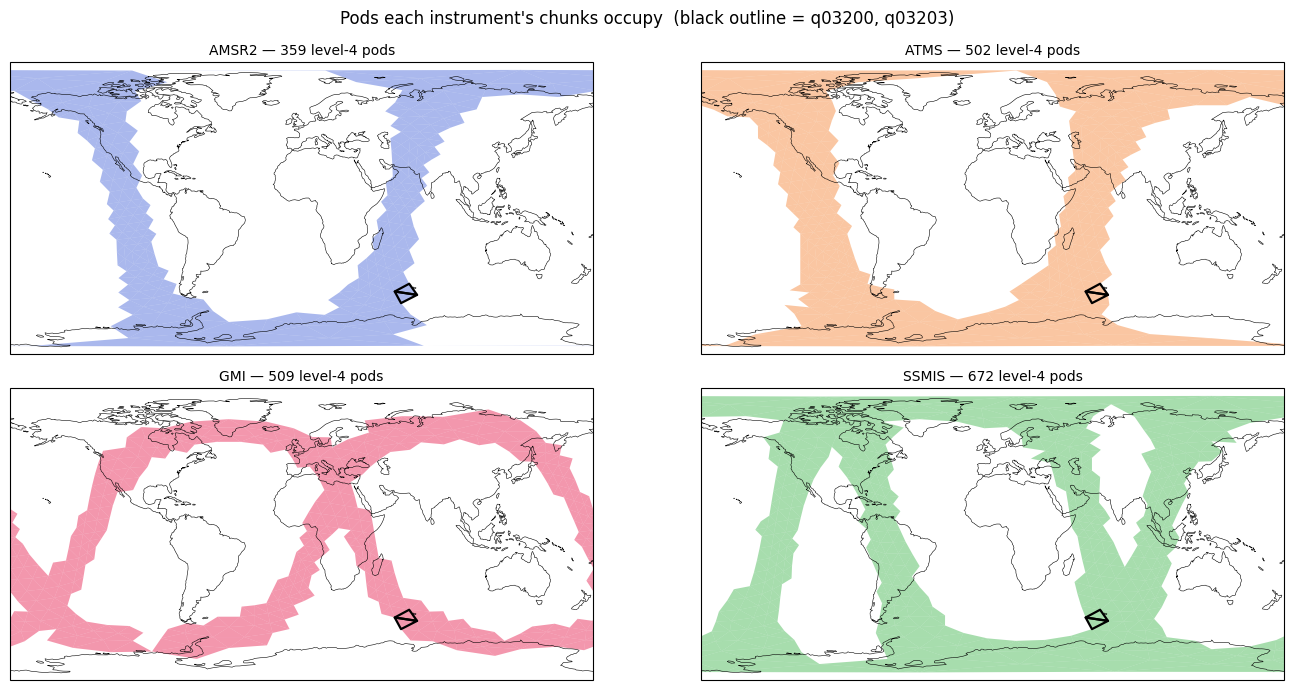

⏱  cell [15] took 2.27s


In [15]:
from starepandas.demo_plots import (
    plot_pod_coverage, plot_rendezvous, pod_pixels, rendezvous_of_size,
)

quad_pods = list(pod_table[pod_table[widest].gt(0)].index)
fig = plot_pod_coverage(demo_catalog, highlight=quad_pods)

## Step 12 — A 4-way rendezvous up close: where *and* when

A rendezvous needs **both** halves, and one map cannot show them. Left: the swaths inside the pod's trixel — pods are triangles, this one ~500 km across. Right: each instrument's pass window over that pod, all landing inside a single Δt.

Note the granularity: co-location here means *the same level-4 pod*, not the same pixel — the swaths need not physically touch. That is the unit the slide-8/9 analytics count.

Steps 13 and 14 repeat this view for narrower rendezvous. Each picks a pod whose widest rendezvous is **exactly** that many instruments — otherwise a "2-way" would be illustrated with a pod that also holds a 4-way — and among those, the pod whose *least*-covered participant still covers the most pixels, so the picture is legible.

INFO:starepandas.demo_lib:Downloading intersecting partitions for ['GMI_S2', 'GMI_S1', 'AMSR2_S1', 'AMSR2_S2', 'AMSR2_S3', 'AMSR2_S4', 'AMSR2_S5', 'AMSR2_S6', 'ATMS_S1', 'ATMS_S2', 'SSMIS_S2', 'SSMIS_S3', 'SSMIS_S4', 'SSMIS_S1']


INFO:starepandas.demo_lib:Processing 1 partitions for GMI_S2


INFO:starepandas.demo_lib:✓ Combined 3363 rows for GMI_S2


INFO:starepandas.demo_lib:Processing 1 partitions for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 3776 rows for GMI_S1


...

INFO:starepandas.demo_lib:✓ Combined 1615 rows for SSMIS_S4


INFO:starepandas.demo_lib:Processing 2 partitions for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 835 rows for SSMIS_S1


INFO:starepandas.demo_lib:Downloaded data for 14 instruments


Pod q03200: 4 instruments, rendezvous completes 2025-01-01 22:13:52.800000
  SSMIS     439 px  2025-01-01 21:28:59.716000 .. 2025-01-01 21:30:04.274000
  AMSR2    1102 px  2025-01-01 21:46:25.459000 .. 2025-01-01 21:47:13.454000
  ATMS      284 px  2025-01-01 21:47:39.136000 .. 2025-01-01 21:49:31.136000
  GMI      7139 px  2025-01-01 22:13:52.800000 .. 2025-01-01 22:16:30.299000


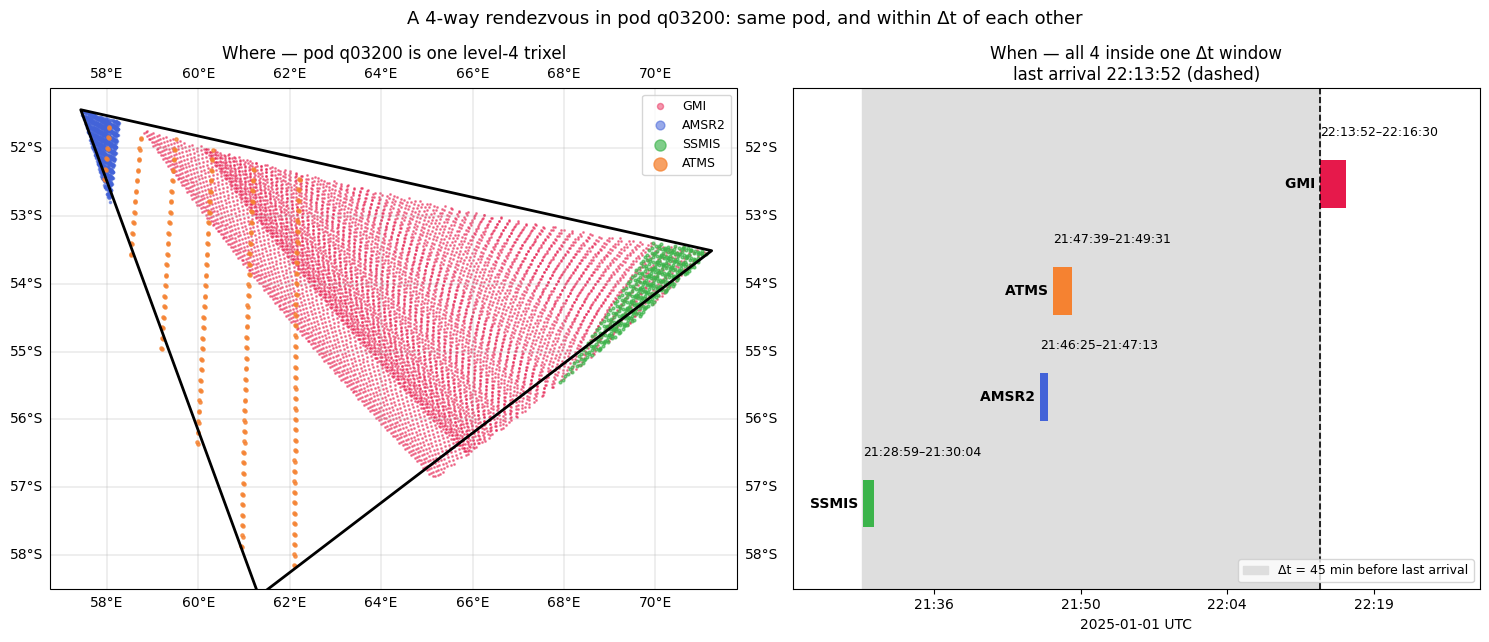

⏱  cell [16] took 9.13s


In [16]:
demo_meta = load_s3_metadata(path_prefix=DEMO_PATH_PREFIX)

pod, meeting, n_way = rendezvous_of_size(events, 4, metadata=demo_meta)
window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
passes = pod_pixels(demo, demo_meta, pod, window)

print(f"Pod {pod}: {n_way} instruments, rendezvous completes {meeting}")
for instrument, pixels in sorted(passes.items(), key=lambda kv: kv[1]['timestamp'].min()):
    print(f"  {instrument:6s} {len(pixels):6d} px  "
          f"{pixels['timestamp'].min()} .. {pixels['timestamp'].max()}")

fig = plot_rendezvous(pod, passes, meeting, OVERLAP_DT)

## Step 13 — A 3-way rendezvous up close

The same view for a **trio**. Three instruments crossing one pod inside the window — the n=3 column of the slide-9 table made concrete.

INFO:starepandas.demo_lib:Downloading intersecting partitions for ['AMSR2_S1', 'AMSR2_S2', 'AMSR2_S3', 'AMSR2_S4', 'AMSR2_S5', 'AMSR2_S6', 'ATMS_S2', 'ATMS_S1', 'SSMIS_S3', 'SSMIS_S4', 'SSMIS_S1', 'SSMIS_S2']


INFO:starepandas.demo_lib:Processing 1 partitions for AMSR2_S1


INFO:starepandas.demo_lib:✓ Combined 4409 rows for AMSR2_S1


INFO:starepandas.demo_lib:Processing 1 partitions for AMSR2_S2


INFO:starepandas.demo_lib:✓ Combined 4413 rows for AMSR2_S2


...

INFO:starepandas.demo_lib:✓ Combined 1455 rows for SSMIS_S1


INFO:starepandas.demo_lib:Processing 1 partitions for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 1454 rows for SSMIS_S2


INFO:starepandas.demo_lib:Downloaded data for 12 instruments


Pod q33330: 3 instruments, rendezvous completes 2025-01-01 21:53:55.415000
  SSMIS    7718 px  2025-01-01 21:36:25.910000 .. 2025-01-01 21:38:54.009000
  AMSR2   35477 px  2025-01-01 21:53:55.415000 .. 2025-01-01 21:56:26.901000
  ATMS     2575 px  2025-01-01 21:56:24.469000 .. 2025-01-01 21:58:35.136000


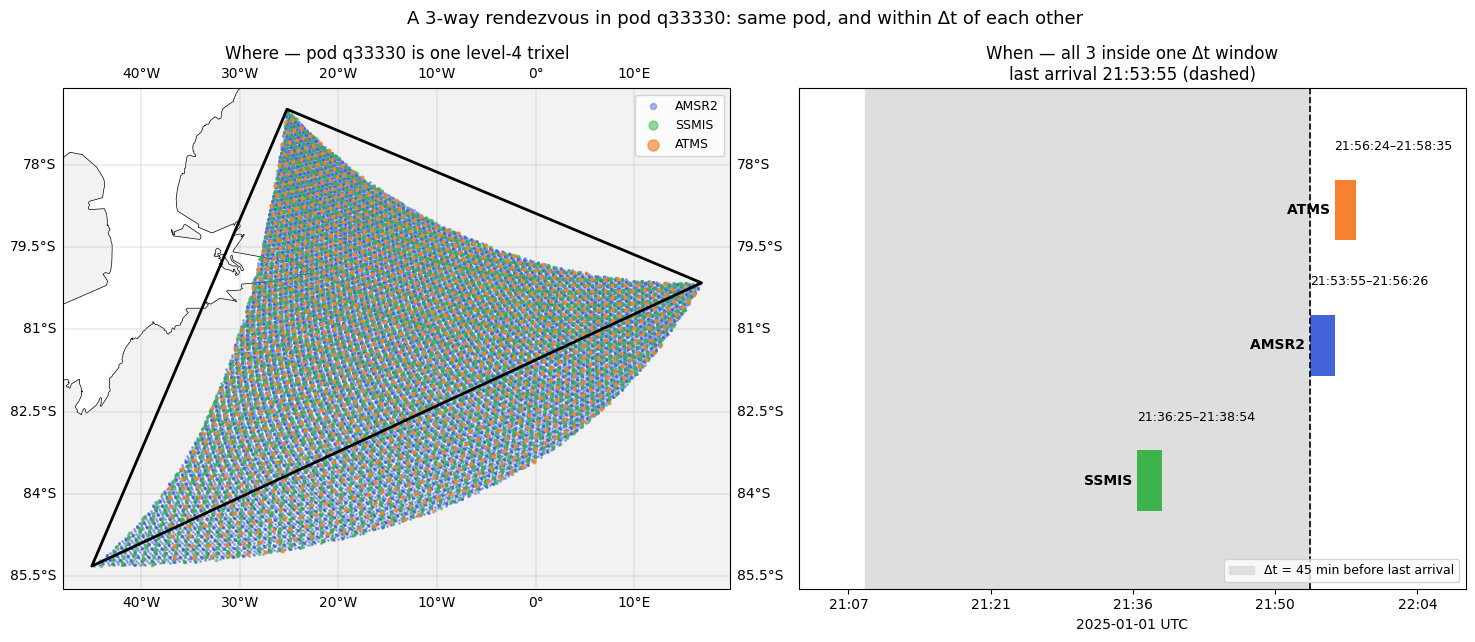

⏱  cell [17] took 8.15s


In [17]:
pod, meeting, n_way = rendezvous_of_size(events, 3, metadata=demo_meta)
window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
passes = pod_pixels(demo, demo_meta, pod, window)

print(f"Pod {pod}: {n_way} instruments, rendezvous completes {meeting}")
for instrument, pixels in sorted(passes.items(), key=lambda kv: kv[1]['timestamp'].min()):
    print(f"  {instrument:6s} {len(pixels):6d} px  "
          f"{pixels['timestamp'].min()} .. {pixels['timestamp'].max()}")

fig = plot_rendezvous(pod, passes, meeting, OVERLAP_DT)

## Step 14 — A 2-way rendezvous up close

And a **pair** — the tightest rendezvous in the demo data: the co-located GMI+SSMIS granules, whose ground tracks cross the same pod within about two minutes of each other.

INFO:starepandas.demo_lib:Downloading intersecting partitions for ['GMI_S2', 'GMI_S1', 'SSMIS_S2', 'SSMIS_S3', 'SSMIS_S4', 'SSMIS_S1']


INFO:starepandas.demo_lib:Processing 2 partitions for GMI_S2


INFO:starepandas.demo_lib:✓ Combined 7111 rows for GMI_S2


INFO:starepandas.demo_lib:Processing 2 partitions for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 7109 rows for GMI_S1


...

INFO:starepandas.demo_lib:✓ Combined 2909 rows for SSMIS_S4


INFO:starepandas.demo_lib:Processing 1 partitions for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 1428 rows for SSMIS_S1


INFO:starepandas.demo_lib:Downloaded data for 6 instruments


Pod q23032: 2 instruments, rendezvous completes 2025-01-01 12:54:47.805000
  GMI      4832 px  2025-01-01 12:53:09.852000 .. 2025-01-01 12:54:54.851000
  SSMIS    8798 px  2025-01-01 12:54:47.805000 .. 2025-01-01 12:57:34.889000


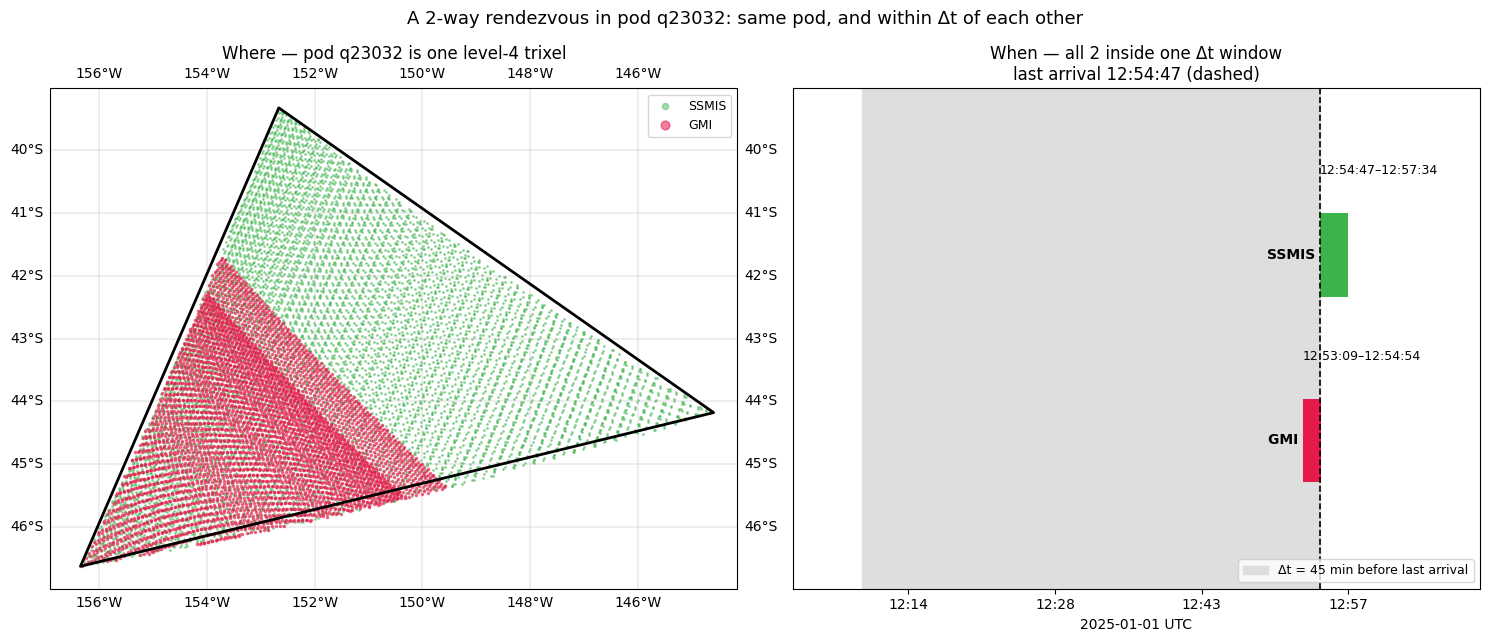

⏱  cell [18] took 3.72s


In [18]:
pod, meeting, n_way = rendezvous_of_size(events, 2, metadata=demo_meta)
window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
passes = pod_pixels(demo, demo_meta, pod, window)

print(f"Pod {pod}: {n_way} instruments, rendezvous completes {meeting}")
for instrument, pixels in sorted(passes.items(), key=lambda kv: kv[1]['timestamp'].min()):
    print(f"  {instrument:6s} {len(pixels):6d} px  "
          f"{pixels['timestamp'].min()} .. {pixels['timestamp'].max()}")

fig = plot_rendezvous(pod, passes, meeting, OVERLAP_DT)

## Run time summary

Where the wall clock actually went, slowest cell first.

In [19]:
timings = pd.Series(CELL_TIMINGS, name='seconds').sort_index()
timings.index.name = 'In [n]'
print(f"{len(timings)} timed cells, {timings.sum():.1f}s total "
      f"({timings.sum() / 60:.1f} min) — excluding this summary cell itself")
display(timings.sort_values(ascending=False).head(10).round(2).to_frame())

15 timed cells, 144.9s total (2.4 min) — excluding this summary cell itself


,seconds
In [n],
8,112.33
16,9.13
17,8.15
18,3.72
11,3.29
12,2.35
15,2.27
5,1.05
14,0.95


⏱  cell [19] took 0.00s
